In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle
import scipy
import os
from sklearn.linear_model import LinearRegression
import difflib
from matplotlib.colors import LinearSegmentedColormap, Normalize
from IPython.display import display, HTML
sns.set_context(rc={'lines.linewidth': 2.5,
					'axes.labelsize': 25,
					'axes.titlesize': 19.200000000000003,
					'font.size': 25,
					'xtick.major.width': 8,
					'ytick.major.width': 8,
					'xtick.major.size':6,
					'ytick.major.size':6,
					'axes.linewidth':4})
display(HTML("<style>.container { width:85% !important; }</style>"))

Inits.

In [ ]:
full_data = pd.read_pickle('multifiber_data_reviews.pickle')
# region and indexing-related variables / functions
region_ids = ['PrL (E)', 'PrL (I)', 'vLS (E)', 'vLS (I)', 'POA (E)', 'POA (I)',
	'BNST (E)', 'BNST (I)', 'AH (E)', 'AH (I)', 'MeA (E)', 'MeA (I)',
	'VMH (E)', 'VMH (I)', 'PAG (E)', 'PAG (I)', 'PMv (E)', 'PMv (I)', 'LHb (E)', 'LHb (I)',
	'PA (E)', 'PA (I)', 'NAc (DA)'] # populations
indices = {val: idx for idx, val in enumerate(region_ids)} # dictionary with IDs for remapping
agg_animals = ['3095', '3096', '3097', '4013', '4014', '4015', '4016', '91R2', '30L', '30B', '31R2', '29L2']
obs_animals = ['30R2', '29L', '86L', '87L2', '927R', '927L', '933R', '1162B', '1185']
non_animals = ['87R2', '87L', '87B', '86L2', '583L2', '583B', '1162L2', '1162R']
xpo_animals = ['4321L', '4321L2', '4321R', '7452R', '7452L2']
animals = np.concatenate([agg_animals, obs_animals, non_animals])
clusters = np.unique(full_data['91R2_d1_balbc_t1']['unsupervised labels'])
print(clusters)

### Computing and evaluating neural activity similarity between groups

In [5]:
animals = np.concatenate([agg_animals, obs_animals, non_animals, xpo_animals])
all_activity = np.zeros((len(clusters), len(region_ids), 27, len(animals)))
all_activity[:] = np.nan

for a, animal in enumerate(animals):
	
	if a<=11:
		sessions = [x for x in list(full_data.keys()) if animal in x if '_balbc_' in x or '_mCD1_' in x]
	elif a<=20:
		sessions = [x for x in list(full_data.keys()) if animal in x if '_obs_' in x or '_OBSmCD1_' in x]
	elif a<=28:
		sessions = [x for x in list(full_data.keys()) if animal in x if '_toy_' in x or '_toyCD1_' in x]
	else:
		sessions = [x for x in list(full_data.keys()) if animal in x if '_xpo_' in x or '_xpoCD1_' in x]
		
	for s, session in enumerate(sessions):
		
		sample = full_data[session]
		activity_per_cluster = np.zeros((len(clusters), all_activity.shape[1]))

		for i, c in enumerate(clusters):
			idxs2extract = np.where(sample['unsupervised labels'] == c)[0]
			for r, roi in enumerate(region_ids):
				if len(idxs2extract)==0:
					activity_per_cluster[i, r] = 0
				else:
					activity_per_cluster[i, r] = np.nanmean(sample[roi].iloc[idxs2extract])

		# Perform ranking
		all_activity[:, :, s, a] = activity_per_cluster
		

C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_18884\2489471760.py:27: RuntimeWarning: Mean of empty slice
  activity_per_cluster[i, r] = np.nanmean(sample[roi].iloc[idxs2extract])


In [6]:
all_activity[:, :, -3:, 29:] = all_activity[:, :, 0:3, 29:]
all_activity[:, :, 0:3, 29:] = np.nan

Compute distance statistics

In [19]:
from scipy.spatial import distance
from scipy.spatial.distance import cdist

def safe_cosine(a, b):
    if np.any(np.isnan(a)) or np.any(np.isnan(b)):
        return np.nan
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)
    if norm_a == 0 or norm_b == 0:
        return np.nan
    return np.clip(1.0 - np.dot(a, b) / (norm_a * norm_b), 0, 2)

# --- Main loop ---
def create_cluster_vectors(grid, n_clusters, n_animals=12):
    EI_grid = np.zeros((len(n_clusters), 23, grid.shape[2], n_animals))
    EI_grid[:] = np.nan
    for a in range(grid.shape[-1]):
        for i, idx in enumerate(np.arange(23)):
            roi = grid[n_clusters, idx, :, a]
            EI_grid[:, i, :, a] = roi
    return EI_grid

n_clusters     = np.arange(13)
total_sessions = 27
n_rois         = len(region_ids)
n_animals      = len(animals)

activity_vectors = np.zeros((len(n_clusters), n_rois, 27, n_animals))
activity_vectors[:, :, :, :] = create_cluster_vectors(all_activity[:, :, :, :], n_clusters=np.array(n_clusters), n_animals=n_animals)

all_dists        = np.zeros((total_sessions, n_rois, n_animals, n_animals)); all_dists[:] = np.nan
all_cosines      = all_dists.copy()
all_soft_cosines = all_dists.copy()

for animal in np.arange(activity_vectors.shape[-1]):
    for roi in np.arange(n_rois):
        sample = activity_vectors[:, roi, :, animal]
        for second_animal in np.arange(activity_vectors.shape[-1]):
            if second_animal == animal:
                continue
            second_sample = activity_vectors[:, roi, :, second_animal]
            for session in np.arange(second_sample.shape[-1]):
                a = sample[:, session]
                b = second_sample[:, session]
                if np.all(np.isnan(b)):
                    continue
                all_cosines[session, roi, animal, second_animal] = safe_cosine(a, b)

Compute within-group distances and compare to across-group distances.

Hard fight distributions

1. OBS vs ALL

In [21]:
from scipy.stats import ks_2samp
dist_vector = all_cosines.copy()
# Assessing distributions during hard fight
t1 = -3
t2 = None
obs_non = dist_vector[-3:, :, np.arange(12, 21), :][:, :, :, np.arange(21, 29)]
# obs_non = np.median(obs_non, axis=0)
obs_aggro = dist_vector[-3:, :, np.arange(12, 21), :][:, :, :, :12]
# obs_aggro = np.median(obs_aggro, axis=0)

# Inits
best_idxs = [12, 16, 8, 4, 10, 20, 6, 14, 2, 0, 18, 13, 17, 9, 5, 11, 21, 7, 15, 3, 1, 19, 22]
indices_with_E = np.array([i for i, region in enumerate(region_ids) if "(E)" in region])
indices_with_I = np.array([i for i, region in enumerate(region_ids) if "(I)" in region])
indices_with_DA = np.array([i for i, region in enumerate(region_ids) if "DA" in region])
corrected_indices = np.concatenate([indices_with_E, indices_with_I, indices_with_DA])

# Stats with multiple comparisons
p_values = []
ks_stats = []
for r, region in enumerate(best_idxs):
	try:
		distb1 = obs_aggro[:, region].flatten() # flatten in order to assess all comparisons
		distb1 = distb1[~np.isnan(distb1)]
		distb2 = obs_non[:, region].flatten()
		distb2 = distb2[~np.isnan(distb2)]
	except IndexError:
		distb1 = obs_aggro[region]
		distb1 = distb1[~np.isnan(distb1)]
		distb2 = obs_non[region]
		distb2 = distb2[~np.isnan(distb2)]
	ks_statistic, p_value = ks_2samp(distb1, distb2)
	p_values.append(p_value)
	ks_stats.append(ks_statistic)

from statsmodels.stats.multitest import multipletests
reject, pvals_corrected, _, _ = multipletests(p_values, method='bonferroni')
ks_stats = np.array(ks_stats)
pvals_uncorrected = np.array(p_values)
rows = []
for r, region in enumerate([region_ids[x] for x in best_idxs]):
	print('%s: KS = %f, p = %f' % (region, ks_stats[r], pvals_corrected[r]))
	# rows.append('KS = %f, p = %f' % (ks_stats[r], pvals_uncorrected[r]))
	rows.append('p = %f' % pvals_corrected[r])


VMH (E): KS = 0.143519, p = 0.204672
PMv (E): KS = 0.222222, p = 0.000449
AH (E): KS = 0.216667, p = 0.000477
POA (E): KS = 0.135522, p = 0.417594
MeA (E): KS = 0.303872, p = 0.000000
PA (E): KS = 0.182099, p = 0.019774
BNST (E): KS = 0.135185, p = 0.521791
PAG (E): KS = 0.162037, p = 0.156538
vLS (E): KS = 0.140432, p = 0.257535
PrL (E): KS = 0.118687, p = 1.000000
LHb (E): KS = 0.283436, p = 0.000000
VMH (I): KS = 0.203704, p = 0.000843
PMv (I): KS = 0.256173, p = 0.000010
AH (I): KS = 0.083333, p = 1.000000
POA (I): KS = 0.156566, p = 0.087615
MeA (I): KS = 0.254630, p = 0.000003
PA (I): KS = 0.213992, p = 0.001038
BNST (I): KS = 0.125000, p = 0.994541
PAG (I): KS = 0.087963, p = 1.000000
vLS (I): KS = 0.146605, p = 0.161843
PrL (I): KS = 0.086279, p = 1.000000
LHb (I): KS = 0.185700, p = 0.014524
NAc (DA): KS = 0.116162, p = 1.000000


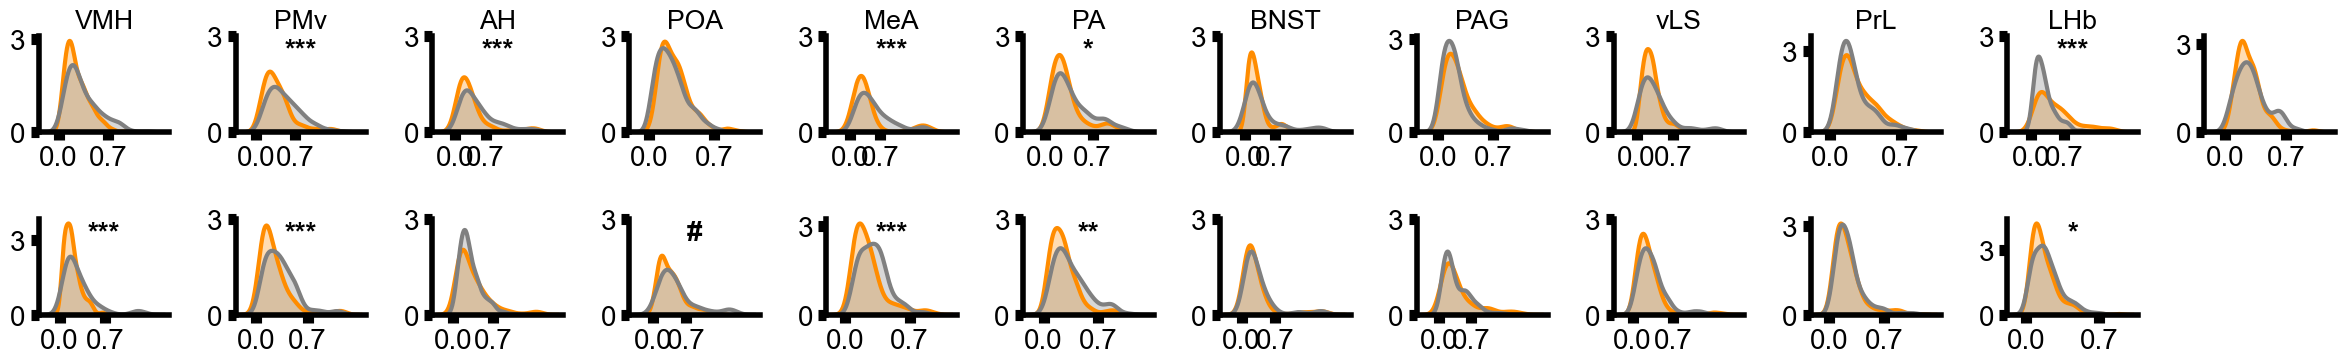

In [22]:
# Plot KDE distributions

# Set Arial as default font for all matplotlib text
plt.rcParams['font.family'] = 'Arial'

# Plot hard fight comparisons - inverted structure: 2 rows, 12 columns
fig, ax = plt.subplots(2, 12, figsize=(24, 4.2))

for r, region in enumerate(best_idxs):
	try:
		distb1 = obs_aggro[:, region].flatten()
		distb1 = distb1[~np.isnan(distb1)]
		distb2 = obs_non[:, region].flatten()
		distb2 = distb2[~np.isnan(distb2)]
	except IndexError:
		distb1 = obs_aggro[region].flatten()
		distb1 = distb1[~np.isnan(distb1)]
		distb2 = obs_non[region].flatten()
		distb2 = distb2[~np.isnan(distb2)]
		
	p_val = pvals_corrected[r]

	# Plot KDEs with inverted indexing
	if r < 11:
		row = 0
		col = r
		ax[row, col].set_title(region_ids[region].split(' ')[0], color='black', fontfamily='Arial')
	elif r < 22:
		row = 1
		col = r - 11
	else:
		row = 0
		col = r - 11
		
	sns.kdeplot(distb1, ax=ax[row, col], color='darkorange', multiple='layer', fill=True, alpha=0.3, lw=0)
	sns.kdeplot(distb1, ax=ax[row, col], color='darkorange', lw=3)
	sns.kdeplot(distb2, ax=ax[row, col], color='gray', multiple='layer', fill=True, alpha=0.3, lw=0)
	sns.kdeplot(distb2, ax=ax[row, col], color='gray', lw=3) 
	ax[row, col].set_ylabel('')
	ax[row, col].set_xticks([0, 0.7])
	ax[row, col].set_yticks([0, 3])
	ax[row, col].tick_params(axis='x', labelsize=20)
	ax[row, col].tick_params(axis='y', labelsize=20)
	
	# Set tick label font to Arial
	for label in ax[row, col].get_xticklabels():
		label.set_fontfamily('Arial')
	for label in ax[row, col].get_yticklabels():
		label.set_fontfamily('Arial')
	  
	# Get p-value and determine significance level
	if p_val < 0.001:
		sig_text = '***'
	elif p_val < 0.01:
		sig_text = '**'
	elif p_val < 0.05:
		sig_text = '*'
	elif p_val < 0.1:
		sig_text = '#'
	else:
		sig_text = ''

	# Add asterisk if significant
	if sig_text:
		ax[row, col].text(0.5, 0.99, sig_text, transform=ax[row, col].transAxes, 
						 fontsize=20, fontweight='bold', ha='center', va='top', fontfamily='Arial')

	sns.despine()

# Remove empty axes (last column of second row)
fig.delaxes(ax[1, 11])
plt.tight_layout()
plt.savefig('.\\figures\\fig4\\obs_non_aggro_distributions_HF.svg', dpi=300)

In [23]:
from scipy.stats import ttest_ind, mannwhitneyu, shapiro

# Assessing mean differences - same as above
t1 = -3
t2 = None
obs_non = dist_vector[-3:, :, np.arange(12, 21), :][:, :, :, np.arange(21, 29)]
obs_aggro = dist_vector[-3:, :, np.arange(12, 21), :][:, :, :, :12]

# Inits
best_idxs = [12, 16, 8, 4, 10, 20, 6, 14, 2, 0, 18, 13, 17, 9, 5, 11, 21, 7, 15, 3, 1, 19, 22]
indices_with_E = np.array([i for i, region in enumerate(region_ids) if "(E)" in region])
indices_with_I = np.array([i for i, region in enumerate(region_ids) if "(I)" in region])
indices_with_DA = np.array([i for i, region in enumerate(region_ids) if "DA" in region])
corrected_indices = np.concatenate([indices_with_E, indices_with_I, indices_with_DA])

# Stats with multiple comparisons
p_values = []
all_stats = []
stat_type = []
for r, region in enumerate(best_idxs):
	try:
		distb1 = obs_aggro[:, region].flatten() # flatten in order to assess all comparisons
		distb1 = distb1[~np.isnan(distb1)]
		distb2 = obs_non[:, region].flatten()
		distb2 = distb2[~np.isnan(distb2)]
	except IndexError:
		distb1 = obs_aggro[region]
		distb1 = distb1[~np.isnan(distb1)]
		distb2 = obs_non[region]
		distb2 = distb2[~np.isnan(distb2)]

	# Statistical test - check normality for independent samples test
	_, p_norm1 = shapiro(distb1)
	_, p_norm2 = shapiro(distb2)
	
	if p_norm1 > 0.05 and p_norm2 > 0.05:
		# Both samples are normally distributed, use independent t-test
		stat, p_val = ttest_ind(distb1, distb2)
		stat_type.append('t = ')
	else:
		# At least one sample is not normally distributed, use Mann-Whitney U test
		stat, p_val = mannwhitneyu(distb1, distb2)
		stat_type.append('U = ')
	p_values.append(p_val)
	all_stats.append(stat)

from statsmodels.stats.multitest import multipletests
reject, pvals_corrected, _, _ = multipletests(p_values, method='fdr_bh')
all_stats = np.array(all_stats)
pvals_uncorrected = np.array(p_values)
rows = []
for r, region in enumerate([region_ids[x] for x in best_idxs]):
    try:
        distb1 = obs_aggro[:, best_idxs[r]].flatten()
        distb1 = distb1[~np.isnan(distb1)]
        distb2 = obs_non[:, best_idxs[r]].flatten()
        distb2 = distb2[~np.isnan(distb2)]
    except IndexError:
        distb1 = obs_aggro[best_idxs[r]]
        distb1 = distb1[~np.isnan(distb1)]
        distb2 = obs_non[best_idxs[r]]
        distb2 = distb2[~np.isnan(distb2)]

    sig = get_sig(pvals_corrected[r])
    print(f'{region:<20} {stat_type[r]}{all_stats[r]:>10.3f}  '
          f'p_raw={pvals_uncorrected[r]:.4f}  '
          f'p_fdr={pvals_corrected[r]:.4f} {sig:<4}  '
          f'n_agg={len(distb1):>6}  n_non={len(distb2):>6}')
    rows.append({
        'region':   region,
        'test':     stat_type[r].strip(),
        'stat':     all_stats[r],
        'p_raw':    pvals_uncorrected[r],
        'p_fdr':    pvals_corrected[r],
        'sig':      sig,
        'n_agg':    len(distb1),
        'n_non':    len(distb2),
    })

df = pd.DataFrame(rows)
print(f'\n{"="*70}')
print(f'Total regions: {len(rows)}  |  '
      f'Significant (FDR<0.05): {(df["p_fdr"]<0.05).sum()}')

VMH (E)              U =  28333.000  p_raw=0.0002  p_fdr=0.0005 ***   n_agg=   324  n_non=   216
PMv (E)              U =  19110.000  p_raw=0.0000  p_fdr=0.0000 ***   n_agg=   243  n_non=   216
AH (E)               U =  21545.000  p_raw=0.0000  p_fdr=0.0000 ***   n_agg=   270  n_non=   216
POA (E)              U =  36413.000  p_raw=0.0089  p_fdr=0.0146 *     n_agg=   297  n_non=   216
MeA (E)              U =  22250.000  p_raw=0.0000  p_fdr=0.0000 ***   n_agg=   297  n_non=   216
PA (E)               U =  21286.000  p_raw=0.0005  p_fdr=0.0011 **    n_agg=   243  n_non=   216
BNST (E)             U =  25742.000  p_raw=0.0263  p_fdr=0.0378 *     n_agg=   270  n_non=   216
PAG (E)              U =  27171.000  p_raw=0.0031  p_fdr=0.0054 **    n_agg=   216  n_non=   216
vLS (E)              U =  31937.000  p_raw=0.0855  p_fdr=0.0983       n_agg=   324  n_non=   216
PrL (E)              U =  35690.000  p_raw=0.0293  p_fdr=0.0396 *     n_agg=   297  n_non=   216
LHb (E)              U =  3547

C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_25816\1415744575.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[row, col].set_xticklabels(['', ''])
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_25816\1415744575.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[row, col].set_xticklabels(['', ''])
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_25816\1415744575.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[row, col].set_xticklabels(['', ''])
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_25816\1415744575.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[row, col].set_xticklabels(['', ''])
C:\Users\FalknerLab\AppData\Loca

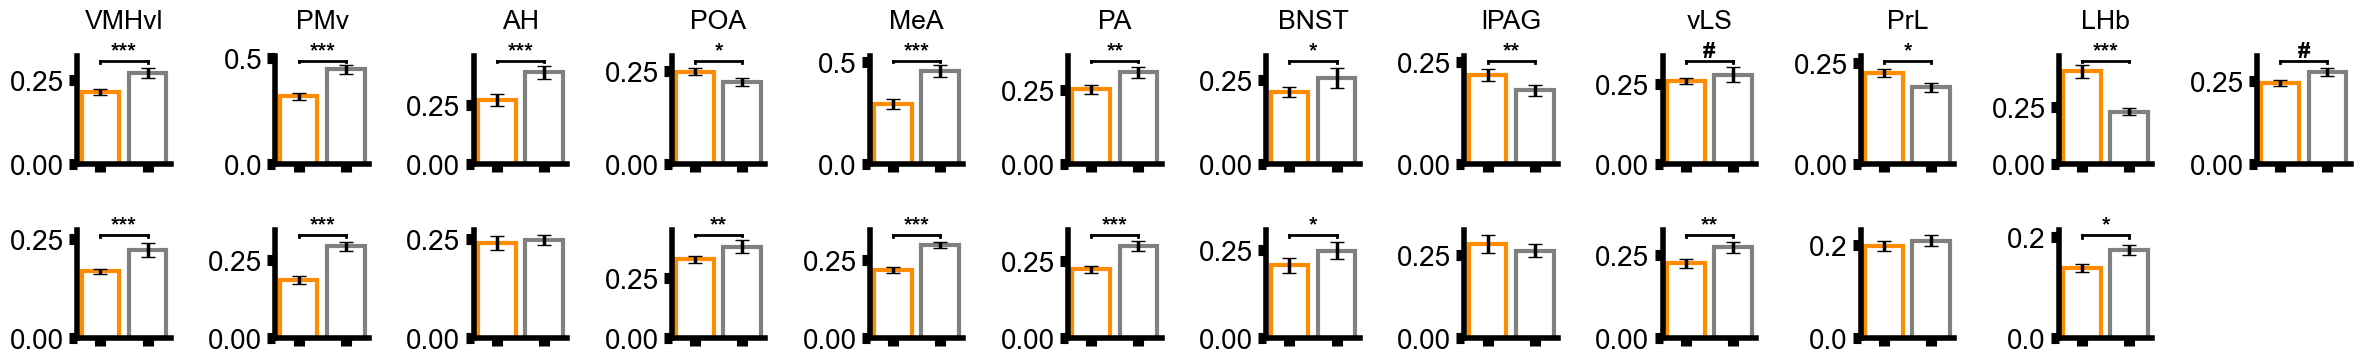

In [287]:
# Plot bar plots for means

# Set Arial as default font for all matplotlib text
plt.rcParams['font.family'] = 'Arial'

# Create figure with 2 rows and 12 columns for bar plots
fig, ax = plt.subplots(2, 12, figsize=(24, 4.2))

for r, region in enumerate(best_idxs):
	try:
		distb1 = obs_aggro[:, region].flatten()
		distb1 = distb1[~np.isnan(distb1)]
		distb2 = obs_non[:, region].flatten()
		distb2 = distb2[~np.isnan(distb2)]
	except IndexError:
		distb1 = obs_aggro[region].flatten()
		distb1 = distb1[~np.isnan(distb1)]
		distb2 = obs_non[region].flatten()
		distb2 = distb2[~np.isnan(distb2)]
	
	p_val = pvals_corrected[r]
	
	# Calculate means and SEMs
	mean_aggro = np.nanmedian(distb1)
	sem_aggro = np.nanstd(distb1) / np.sqrt(len(distb1))
	mean_non = np.nanmedian(distb2)
	sem_non = np.nanstd(distb2) / np.sqrt(len(distb2))
	
	# Determine row and column position
	if r < 11:
		row = 0
		col = r
		ax[row, col].set_title(region_ids[region].split(' ')[0], color='black', fontfamily='Arial', pad=20)
	elif r < 22:
		row = 1
		col = r - 11
	else:
		row = 0
		col = r - 11
	
	# Create bar plot
	bars = ax[row, col].bar(['OBS-AGGRO', 'OBS-NON'], [mean_aggro, mean_non], 
						   yerr=[sem_aggro, sem_non], capsize=5,
						   color='white', alpha=1.0, edgecolor=['darkorange', 'gray'], linewidth=3)
	
	# Remove axis labels but keep tick labels
	ax[row, col].set_ylabel('')
	ax[row, col].set_xlabel('')
	ax[row, col].set_xticklabels(['', ''])
	
	# Set tick label font to Arial and adjust size
	for label in ax[row, col].get_xticklabels():
		label.set_fontfamily('Arial')
		label.set_fontsize(10)
	for label in ax[row, col].get_yticklabels():
		label.set_fontfamily('Arial')
		label.set_fontsize(20)
	
	# Get p-value and determine significance level
	if p_val < 0.001:
		sig_text = '***'
	elif p_val < 0.01:
		sig_text = '**'
	elif p_val < 0.05:
		sig_text = '*'
	elif p_val < 0.1:
		sig_text = '#'
	else:
		sig_text = ''
	
	# Add significance bracket and stars
	if sig_text:
		y_max = max(mean_aggro + sem_aggro, mean_non + sem_non)
		bracket_height = y_max + 0.02
		ax[row, col].plot([0, 1], [bracket_height, bracket_height], 'k-', linewidth=2)
		ax[row, col].plot([0, 0], [bracket_height - 0.005, bracket_height], 'k-', linewidth=2)
		ax[row, col].plot([1, 1], [bracket_height - 0.005, bracket_height], 'k-', linewidth=2)
		ax[row, col].text(0.5, bracket_height - 0.0, sig_text, ha='center', va='bottom', 
						 fontsize=16, fontweight='bold', fontfamily='Arial')

# Remove empty axes (last column of second row)
fig.delaxes(ax[1, 11])
plt.tight_layout()
sns.despine()
plt.savefig('.\\figures\\fig4\\obs_non_aggro_barplots_HF.svg', dpi=300)
plt.show()

In [11]:
# Repeat stats for summary plot

from scipy import stats

new_idx = np.array([12, 16, 8, 4, 10, 20, 6, 14, 2, 0, 18, 13, 17, 9, 5, 11, 21, 7, 15, 3, 1, 22])
p_values = []  # List to collect all p-values
t_values = []
test_types = []

# Assuming your vectors are named vector1, vector2, and vector3
for r, roi in enumerate(region_ids):
	agg_roi_activity = obs_aggro[:, r].flatten()[np.isnan(obs_aggro[:, r].flatten())==False]
	non_roi_activity = obs_non[:, r].flatten()[np.isnan(obs_non[:, r].flatten())==False]

	# Test for normality
	_, p_agg = stats.shapiro(agg_roi_activity)
	_, p_non = stats.shapiro(non_roi_activity)

	# If the p-value is greater than 0.05, the data is normally distributed
	if p_agg > 0.05 and p_non > 0.05:
		# Perform t-tests
		t, p_agg_non = stats.ttest_ind(agg_roi_activity, non_roi_activity)
		test_types.append('t')
	else:
		# Perform Wilcoxon rank-sum tests
		t, p_agg_non = stats.mannwhitneyu(agg_roi_activity, non_roi_activity)
		test_types.append('U')
	p_values.append(p_agg_non) 
	t_values.append(t)
	
# Apply FDR correction
p_values = np.asarray(p_values)[new_idx]
t_values = np.asarray(t_values)[new_idx]
test_types = np.asarray(test_types)[new_idx]
p_adjusted = multipletests(p_values, method='fdr_bh')[1]

# save stats
rows = []
for r, region in enumerate([region_ids[x] for x in new_idx]):
	print('%s: %s = %f, p = %f' % (region, test_types[r], t_values[r], p_adjusted[r]))
	# rows.append('%s = %f, p = %f' % (test_types[r], t_values[r], p_values[r]))
	rows.append('p = %f' % p_adjusted[r])
df = pd.DataFrame(rows, columns=['Values'])
# df.to_excel('data_list.xlsx', index=False)

VMH (E): U = 28333.000000, p = 0.000435
PMv (E): U = 19110.000000, p = 0.000002
AH (E): U = 21545.000000, p = 0.000002
POA (E): U = 36413.000000, p = 0.013979
MeA (E): U = 22250.000000, p = 0.000000
PA (E): U = 21286.000000, p = 0.001043
BNST (E): U = 25742.000000, p = 0.038609
PAG (E): U = 27171.000000, p = 0.005181
vLS (E): U = 31937.000000, p = 0.099002
PrL (E): U = 35690.000000, p = 0.040242
LHb (E): U = 35475.000000, p = 0.000000
VMH (I): U = 26538.000000, p = 0.000005
PMv (I): U = 18521.000000, p = 0.000000
AH (I): U = 29365.000000, p = 0.894252
POA (I): U = 26624.000000, p = 0.001845
MeA (I): U = 23395.000000, p = 0.000001
PA (I): U = 18999.000000, p = 0.000001
BNST (I): U = 25888.000000, p = 0.043304
PAG (I): U = 24042.000000, p = 0.610118
vLS (I): U = 29129.000000, p = 0.001845
PrL (I): U = 30199.000000, p = 0.283391
NAc (DA): U = 28822.000000, p = 0.060721


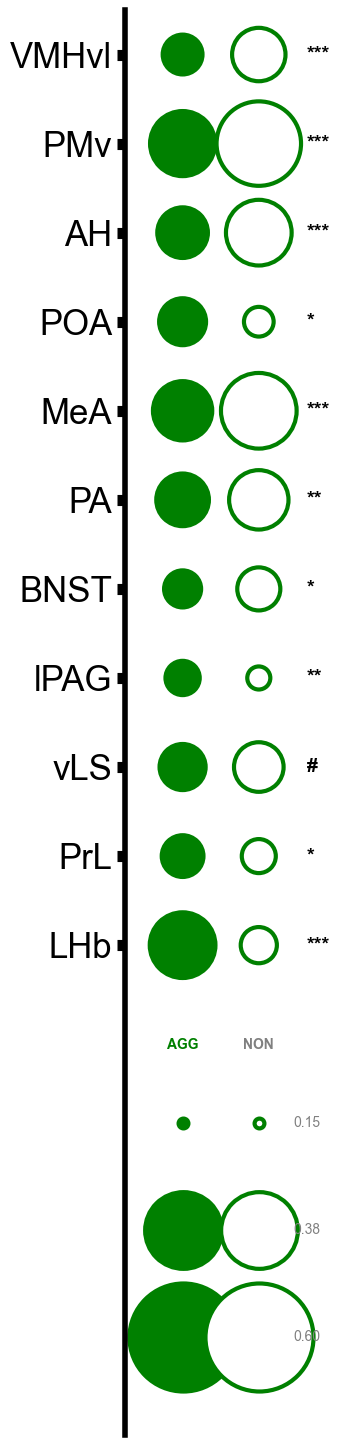

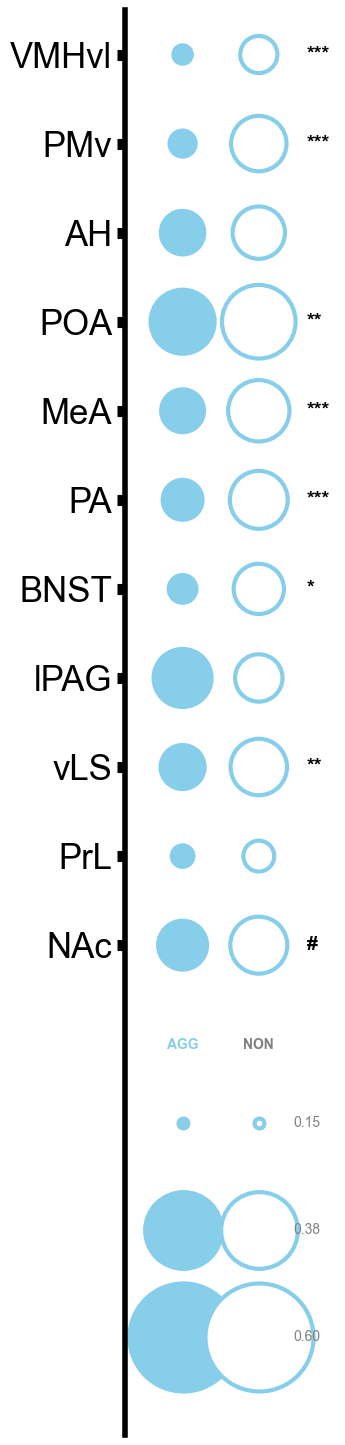

In [ ]:
np.set_printoptions(precision=4, suppress=True)
region_ids = ['PrL (E)', 'PrL (I)', 'vLS (E)', 'vLS (I)', 'POA (E)', 'POA (I)',
	'BNST (E)', 'BNST (I)', 'AH (E)', 'AH (I)', 'MeA (E)', 'MeA (I)',
	'VMHvl (E)', 'VMHvl (I)', 'lPAG (E)', 'lPAG (I)', 'PMv (E)', 'PMv (I)', 'LHb (E)', 'LHb (I)', 
	'PA (E)', 'PA (I)', 'NAc (DA)']

mean_func = np.nanmedian
weights2map_aggro = obs_aggro.copy()
weights2map_aggro = np.transpose(weights2map_aggro, (1, 0, 2, 3))
weights2map_aggro = weights2map_aggro.reshape(23, 27, 12)
weights2map_aggro = mean_func(weights2map_aggro, axis=-1)
weights_aggro     = mean_func(weights2map_aggro, axis=1)

weights2map_non = obs_non.copy()
weights2map_non = np.transpose(weights2map_non, (1, 0, 2, 3))
weights2map_non = weights2map_non.reshape(23, 27, 8)
weights2map_non = mean_func(weights2map_non, axis=-1)
weights_non     = mean_func(weights2map_non, axis=-1)

vmin        = 0.15
vmax        = 0.6
size_factor = 6000

def get_sig_text(p_val):
    if p_val == 0:      return '****'
    elif p_val < 0.001: return '***'
    elif p_val < 0.01:  return '**'
    elif p_val < 0.05:  return '*'
    elif p_val <= 0.1:  return '#'
    else:               return ''

def add_inline_legend(ax, color, vmin, vmax, size_factor,
                      x_aggro, x_non, y_start=-2.5):
    """Draws a mini legend below the data using the same size scale."""
    legend_vals  = [vmin, (vmin + vmax) / 2, vmax]
    legend_sizes = (np.array(legend_vals) - vmin) / (vmax - vmin) * size_factor + 50
    y_leg        = y_start

    for val, sz in zip(legend_vals, legend_sizes):
        # AGG-style (filled) on left column, NON-style (open) on right column
        ax.scatter(x_aggro, y_leg, s=sz, facecolors=color,
                   edgecolors=color, linewidth=3, alpha=1.0, clip_on=False)
        ax.scatter(x_non,   y_leg, s=sz, facecolors='white',
                   edgecolors=color, linewidth=3, alpha=1.0, clip_on=False)
        ax.text(x_non + 0.18, y_leg, f'{val:.2f}',
                ha='left', va='center', fontsize=10, color='gray')
        y_leg -= 1.2

    # Column headers
    ax.text(x_aggro, y_start + 0.8, 'AGG', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color=color)
    ax.text(x_non,   y_start + 0.8, 'NON', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='gray')

# ── Excitatory (no NAc DA) ───────────────────────────────────────────────────
new_idx_E      = np.array([12, 16, 8, 4, 10, 20, 6, 14, 2, 0, 18])[::-1]  # removed 22
weights_aggro_E = weights_aggro[new_idx_E]
weights_non_E   = weights_non[new_idx_E]
labels_E        = [x.replace(' (E)', '').replace(' (I)', '').replace(' (DA)', '')
                   for x in [region_ids[x] for x in new_idx_E]]
pvals_E         = p_adjusted[np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10])][::-1]

n_E    = len(new_idx_E)
y_pos  = np.arange(n_E)
x_agg  = 0.8
x_non  = 1.2
x_sig  = 1.45   # fixed x for sig stars

sizes_aggro_E = (np.clip(weights_aggro_E, vmin, vmax) - vmin) / (vmax - vmin) * size_factor + 50
sizes_non_E   = (np.clip(weights_non_E,   vmin, vmax) - vmin) / (vmax - vmin) * size_factor + 50

fig, ax = plt.subplots(figsize=(4, 15))

ax.scatter(np.ones(n_E) * x_agg, y_pos, s=sizes_aggro_E,
           facecolors='green', edgecolors='green', linewidth=3, alpha=1.0)
ax.scatter(np.ones(n_E) * x_non, y_pos, s=sizes_non_E,
           facecolors='white', edgecolors='green', linewidth=3, alpha=1.0)

for i, p_val in enumerate(pvals_E):
    sig = get_sig_text(p_val)
    if sig:
        ax.text(x_sig, y_pos[i], sig, ha='left', va='center',
                fontsize=14, fontweight='bold', color='black')

add_inline_legend(ax, 'green', vmin, vmax, size_factor,
                  x_aggro=x_agg, x_non=x_non, y_start=-2.0)

ax.set_yticks(y_pos)
ax.set_yticklabels(labels_E, fontsize=25, fontfamily='Arial')
ax.set_xticks([])
ax.set_xlim(0.5, 1.6)
ax.set_ylim(-5.5, n_E - 0.5)
plt.tight_layout()
sns.despine(left=False, bottom=True)
plt.savefig('.\\figures\\fig4\\similarity_points_E_HF.svg', dpi=300)
plt.show()

# ── Inhibitory (with NAc DA appended) ────────────────────────────────────────
new_idx_I      = np.array([13, 17, 9, 5, 11, 21, 7, 15, 3, 1, 22])[::-1]  # added 22
weights_aggro_I = weights_aggro[new_idx_I]
weights_non_I   = weights_non[new_idx_I]
labels_I        = [x.replace(' (E)', '').replace(' (I)', '').replace(' (DA)', '')
                   for x in [region_ids[x] for x in new_idx_I]]
pvals_I         = p_adjusted[np.array([11, 12, 13, 14, 15, 16, 17, 18, 19, 20, -1])][::-1]

n_I    = len(new_idx_I)
y_pos_I = np.arange(n_I)

sizes_aggro_I = (np.clip(weights_aggro_I, vmin, vmax) - vmin) / (vmax - vmin) * size_factor + 50
sizes_non_I   = (np.clip(weights_non_I,   vmin, vmax) - vmin) / (vmax - vmin) * size_factor + 50

fig, ax = plt.subplots(figsize=(4, 15))

ax.scatter(np.ones(n_I) * x_agg, y_pos_I, s=sizes_aggro_I,
           facecolors='skyblue', edgecolors='skyblue', linewidth=3, alpha=1.0)
ax.scatter(np.ones(n_I) * x_non, y_pos_I, s=sizes_non_I,
           facecolors='white', edgecolors='skyblue', linewidth=3, alpha=1.0)

for i, p_val in enumerate(pvals_I):
    sig = get_sig_text(p_val)
    if sig:
        ax.text(x_sig, y_pos_I[i], sig, ha='left', va='center',
                fontsize=14, fontweight='bold', color='black')

add_inline_legend(ax, 'skyblue', vmin, vmax, size_factor,
                  x_aggro=x_agg, x_non=x_non, y_start=-2.0)

ax.set_yticks(y_pos_I)
ax.set_yticklabels(labels_I, fontsize=25, fontfamily='Arial')
ax.set_xticks([])
ax.set_xlim(0.5, 1.6)
ax.set_ylim(-5.5, n_I - 0.5)
plt.tight_layout()
sns.despine(left=False, bottom=True)
plt.savefig('.\\figures\\fig4\\similarity_points_I_HF.svg', dpi=300)
plt.show()

OBS-AGG: E vs I                 U=4705531.000  p_raw=0.0000  p_fdr=0.0000
OBS-NON: E vs I                 U=2747704.000  p_raw=0.0000  p_fdr=0.0000
E: OBS-AGG vs NON               U=2697596.000  p_raw=0.0000  p_fdr=0.0000
I: OBS-AGG vs NON               U=3057751.000  p_raw=0.0000  p_fdr=0.0000


C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_18884\1735324423.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


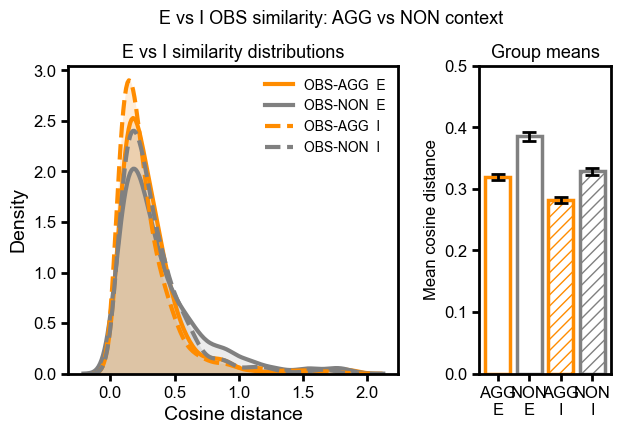

OBS-AGG: E vs I                 U=4705531.000  p_raw=0.0000  p_fdr=0.0000 ***   n_a=  2781  n_b=  3024
OBS-NON: E vs I                 U=2747704.000  p_raw=0.0000  p_fdr=0.0000 ***   n_a=  2160  n_b=  2376
E: OBS-AGG vs NON               U=2697596.000  p_raw=0.0000  p_fdr=0.0000 ***   n_a=  2781  n_b=  2160
I: OBS-AGG vs NON               U=3057751.000  p_raw=0.0000  p_fdr=0.0000 ***   n_a=  3024  n_b=  2376


In [25]:
from scipy.stats import ttest_ind, mannwhitneyu, shapiro
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.rcParams['font.family'] = 'Arial'

# --- Define idxs ---
I_idxs = np.array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19, 21])
E_idxs = np.array([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 20])

# --- Extract E vs I similarities ---
E_obs_aggro = obs_aggro[:, E_idxs]
E_obs_non   = obs_non[:, E_idxs]
I_obs_aggro = obs_aggro[:, I_idxs]
I_obs_non   = obs_non[:, I_idxs]

distb_EA = E_obs_aggro.flatten(); distb_EA = distb_EA[~np.isnan(distb_EA)]
distb_EN = E_obs_non.flatten();   distb_EN = distb_EN[~np.isnan(distb_EN)]
distb_IA = I_obs_aggro.flatten(); distb_IA = distb_IA[~np.isnan(distb_IA)]
distb_IN = I_obs_non.flatten();   distb_IN = distb_IN[~np.isnan(distb_IN)]

# --- Stats: 4 comparisons, FDR-BH corrected ---
def adaptive_test(a, b):
    """MWU if non-normal, t-test if both normal."""
    _, p1 = shapiro(a[:5000] if len(a) > 5000 else a)  # shapiro max N=5000
    _, p2 = shapiro(b[:5000] if len(b) > 5000 else b)
    if p1 > 0.05 and p2 > 0.05:
        stat, p = ttest_ind(a, b)
        return stat, p, 't'
    else:
        stat, p = mannwhitneyu(a, b, alternative='two-sided')
        return stat, p, 'U'

comparisons = {
    'OBS-AGG: E vs I':    (distb_EA, distb_IA),   # cross cell-type, aggro context
    'OBS-NON: E vs I':    (distb_EN, distb_IN),   # cross cell-type, non context
    'E: OBS-AGG vs NON':  (distb_EA, distb_EN),   # within E, group comparison
    'I: OBS-AGG vs NON':  (distb_IA, distb_IN),   # within I, group comparison
}

raw_p, stats_out = [], []
for label, (a, b) in comparisons.items():
    stat, p, test = adaptive_test(a, b)
    raw_p.append(p)
    stats_out.append({'label': label, 'stat': stat, 'p_raw': p, 'test': test})

_, p_corrected, _, _ = multipletests(raw_p, method='fdr_bh')
for i, d in enumerate(stats_out):
    d['p_fdr'] = p_corrected[i]
    print(f"{d['label']:30s}  {d['test']}={d['stat']:.3f}  p_raw={d['p_raw']:.4f}  p_fdr={d['p_fdr']:.4f}")

# --- Plot: single KDE panel + bar panel ---
fig = plt.figure(figsize=(7, 4))
gs  = fig.add_gridspec(1, 2, width_ratios=[2.5, 1], wspace=0.35)
ax_kde = fig.add_subplot(gs[0])
ax_bar = fig.add_subplot(gs[1])

# Color/style scheme: orange = OBS-AGG, gray = OBS-NON; solid = E, dashed = I
kde_specs = [
    (distb_EA, 'darkorange', '-',  'OBS-AGG  E'),
    (distb_EN, 'gray',       '-',  'OBS-NON  E'),
    (distb_IA, 'darkorange', '--', 'OBS-AGG  I'),
    (distb_IN, 'gray',       '--', 'OBS-NON  I'),
]
for dist, color, ls, label in kde_specs:
    sns.kdeplot(dist, ax=ax_kde, color=color, fill=True, alpha=0.15, lw=0)
    sns.kdeplot(dist, ax=ax_kde, color=color, lw=3, linestyle=ls, label=label)

ax_kde.set_xlabel('Cosine distance', fontsize=14)
ax_kde.set_ylabel('Density', fontsize=14)
ax_kde.legend(fontsize=10, frameon=False)
ax_kde.set_title('E vs I similarity distributions', fontsize=13)

# Bar plot: means ± SEM for the 4 vectors
means = [distb_EA.mean(), distb_EN.mean(), distb_IA.mean(), distb_IN.mean()]
sems  = [distb_EA.std()/np.sqrt(len(distb_EA)), distb_EN.std()/np.sqrt(len(distb_EN)),
         distb_IA.std()/np.sqrt(len(distb_IA)), distb_IN.std()/np.sqrt(len(distb_IN))]
colors    = ['darkorange', 'gray', 'darkorange', 'gray']
edgecolors= ['darkorange', 'gray', 'darkorange', 'gray']
hatches   = ['', '', '///', '///']   # hatching distinguishes I from E
xlabels   = ['AGG\nE', 'NON\nE', 'AGG\nI', 'NON\nI']

bars = ax_bar.bar(xlabels, means, yerr=sems, capsize=5,
                  color='white', edgecolor=edgecolors, linewidth=2.5,
                  error_kw=dict(lw=2, capthick=2))
for bar, hatch, ec in zip(bars, hatches, edgecolors):
    bar.set_hatch(hatch)
    bar.set_edgecolor(ec)

# Annotate significant comparisons with brackets
def draw_bracket(ax, x1, x2, y, p, h=0.005):
    """Draw a significance bracket between bar positions x1 and x2."""
    if p < 0.001:   sig = '***'
    elif p < 0.01:  sig = '**'
    elif p < 0.05:  sig = '*'
    else:           sig = 'ns'
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, color='black')
    ax.text((x1+x2)/2, y+h, sig, ha='center', va='bottom', fontsize=11)

ymax = max(m+s for m, s in zip(means, sems))
step = 0.015
# Within-group cross cell-type (E vs I): AGG_E(0) vs AGG_I(2), NON_E(1) vs NON_I(3)
# draw_bracket(ax_bar, 0, 2, ymax + step,   stats_out[0]['p_fdr'])   # OBS-AGG: E vs I
# draw_bracket(ax_bar, 1, 3, ymax + step*3, stats_out[1]['p_fdr'])   # OBS-NON: E vs I
# Within cell-type group comparisons: E_AGG(0) vs E_NON(1), I_AGG(2) vs I_NON(3)
# draw_bracket(ax_bar, 0, 1, ymax + step*5, stats_out[2]['p_fdr'])   # E: AGG vs NON
# draw_bracket(ax_bar, 2, 3, ymax + step*7, stats_out[3]['p_fdr'])   # I: AGG vs NON

ax_bar.set_ylabel('Mean cosine distance', fontsize=12)
ax_bar.set_title('Group means', fontsize=13)

for ax in [ax_kde, ax_bar]:
    ax.tick_params(axis='both', labelsize=12, width=2, length=5)
    for spine in ax.spines.values():
        spine.set_linewidth(2)

plt.suptitle('E vs I OBS similarity: AGG vs NON context', fontsize=13, y=1.02)
ax.set_ylim(top=0.5)
plt.tight_layout()
plt.savefig('.\\figures\\fig4\\obs_non_aggro_E_vs_I_comparison_HF.svg', dpi=300)
plt.show()

for i, d in enumerate(stats_out):
    label = d['label']
    a, b  = list(comparisons.values())[i]
    sig   = get_sig(d['p_fdr'])
    print(f"{label:<30}  {d['test']}={d['stat']:>10.3f}  "
          f"p_raw={d['p_raw']:.4f}  p_fdr={d['p_fdr']:.4f} {sig:<4}  "
          f"n_a={len(a):>6}  n_b={len(b):>6}")

[E] Observed Euclidean dist = 0.2066, p = 0.0277 (n_shuffles=10000)
[I] Observed Euclidean dist = 0.2406, p = 0.0090 (n_shuffles=10000)


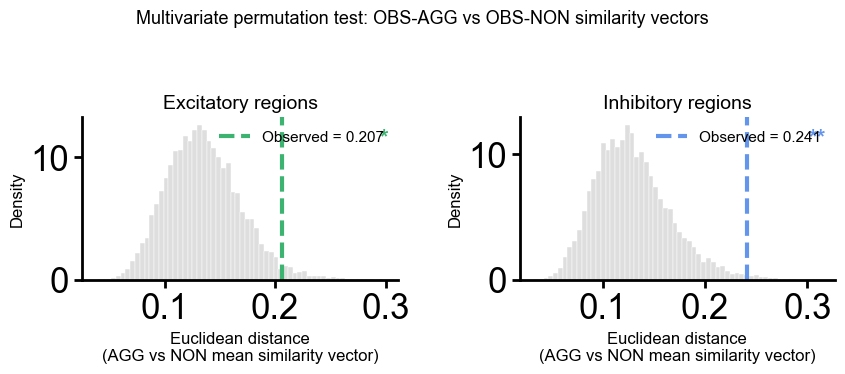

In [ ]:
from scipy.spatial.distance import euclidean

plt.rcParams['font.family'] = 'Arial'

region_ids = ['PrL (E)', 'PrL (I)', 'vLS (E)', 'vLS (I)', 'POA (E)', 'POA (I)',
    'BNST (E)', 'BNST (I)', 'AH (E)', 'AH (I)', 'MeA (E)', 'MeA (I)',
    'VMHvl (E)', 'VMHvl (I)', 'lPAG (E)', 'lPAG (I)', 'PMv (E)', 'PMv (I)', 'LHb (E)', 'LHb (I)', 
    'PA (E)', 'PA (I)', 'NAc (DA)']

E_idxs = np.array([i for i, r in enumerate(region_ids) if '(E)' in r and 'LHb' not in r])  # shape (11,)
I_idxs = np.array([i for i, r in enumerate(region_ids) if '(I)' in r and 'LHb' not in r])  # shape (11,)
area_names = [r.replace(' (E)', '') for r in region_ids if '(E)' in r and 'LHb' not in r]  # 11 paired area names

# ─────────────────────────────────────────────────────────────────────────────
# Multivariate permutation test
# Tests whether the full E (or I) population similarity vector separates
# OBS-AGG from OBS-NON more than chance.
#
# Logic:
#   - Compute per-obs-animal mean similarity vector across regions: (9, n_regions)
#     by averaging over time bins (axis 0) and comparison animals (axis 3)
#   - Observed statistic = Euclidean distance between group mean vectors
#   - Null = shuffle the 20 comparison animals (12 agg + 8 non) and recompute
# ─────────────────────────────────────────────────────────────────────────────

n_shuffles = 10000
rng = np.random.default_rng(42)

# obs_aggro: (3, 23, 9, 12), obs_non: (3, 23, 9, 8)
# Concatenate comparison animals -> (3, 23, 9, 20)
all_comparisons = np.concatenate([obs_aggro, obs_non], axis=3)
n_agg_animals = obs_aggro.shape[3]   # 12
n_non_animals = obs_non.shape[3]     # 8
n_comp_total  = all_comparisons.shape[3]  # 20

def group_mean_vector(data, region_subset):
    """
    Mean similarity vector per obs animal for a given region subset.
    data: (3, 23, 9, n_comp)
    returns: (9, n_regions_subset) - one vector per obs animal
    """
    sub = data[:, region_subset, :, :]           # (3, n_regions, 9, n_comp)
    return np.nanmedian(sub, axis=(0, 3)).T        # mean over time & comp animals -> (n_regions, 9) -> T -> (9, n_regions)

def observed_stat(data, region_subset, n_agg):
    """Euclidean distance between group mean vectors."""
    vecs_agg = group_mean_vector(data[:, :, :, :n_agg], region_subset)   # (9, n_regions)
    vecs_non = group_mean_vector(data[:, :, :, n_agg:], region_subset)   # (9, n_regions)
    mean_agg = np.nanmedian(vecs_agg, axis=0)  # (n_regions,)
    mean_non = np.nanmedian(vecs_non, axis=0)  # (n_regions,)
    return euclidean(mean_agg, mean_non), mean_agg, mean_non

results_perm = {}
for label, region_subset in [('E', E_idxs), ('I', I_idxs)]:
    obs_stat, mean_agg_vec, mean_non_vec = observed_stat(all_comparisons, region_subset, n_agg_animals)
    
    # Build null distribution
    null_stats = np.zeros(n_shuffles)
    for s in range(n_shuffles):
        shuffled = all_comparisons[:, :, :, rng.permutation(n_comp_total)]
        null_stats[s], _, _ = observed_stat(shuffled, region_subset, n_agg_animals)
    
    p_val = np.mean(null_stats >= obs_stat)  # one-tailed: observed > null
    results_perm[label] = {
        'obs_stat': obs_stat,
        'null_stats': null_stats,
        'p_val': p_val,
        'mean_agg_vec': mean_agg_vec,
        'mean_non_vec': mean_non_vec
    }
    print(f'[{label}] Observed Euclidean dist = {obs_stat:.4f}, p = {p_val:.4f} (n_shuffles={n_shuffles})')

# Plot: null distributions with observed statistic marked
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
colors = {'E': 'mediumseagreen', 'I': 'cornflowerblue'}

for ax, (label, res) in zip(axes, results_perm.items()):
    color = colors[label]
    sns.histplot(res['null_stats'], ax=ax, color='lightgray', edgecolor='white',
                 bins=60, stat='density')
    ax.axvline(res['obs_stat'], color=color, lw=3, linestyle='--',
               label=f"Observed = {res['obs_stat']:.3f}")
    
    p = res['p_val']
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else f'p = {p:.3f}'
    ax.text(0.97, 0.93, sig, transform=ax.transAxes, ha='right', va='top',
            fontsize=16, fontweight='bold', color=color)
    
    ax.set_title(f'{"Excitatory" if label=="E" else "Inhibitory"} regions', fontsize=14)
    ax.set_xlabel('Euclidean distance\n(AGG vs NON mean similarity vector)', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.legend(fontsize=11, frameon=False)
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    ax.tick_params(width=2)

plt.suptitle('Multivariate permutation test: OBS-AGG vs OBS-NON similarity vectors', fontsize=13)
plt.tight_layout()
plt.savefig('.\\figures\\fig4\\permutation_test_EI.svg', dpi=300)
sns.despine()
plt.show()

Training period distributions

In [26]:
# Calculate cross-animal similarity matrices for different cluster numbers - Training period

def soft_cosine(a, b, S):
    if np.any(np.isnan(a)) or np.any(np.isnan(b)):
        return np.nan
    num   = a @ S @ b
    denom = np.sqrt((a @ S @ a) * (b @ S @ b))
    if denom == 0:
        return np.nan
    return np.clip(1 - num / denom, 0, 2)

# Precompute S from activity vectors (cluster co-activation structure)
cluster_groups = [
    [0, 1, 2, 3],       # aggression
    [4, 6, 7, 8],       # investigative (0-indexed: clusters 5,7,8,9 -> 4,6,7,8)
    [5, 9, 10, 11, 12], # avoidance / disengagement
]

# Soft cosine config
within_sim   = 1  # same cluster
neighbor_sim = 0.8  # same group, different cluster
across_sim   = 0.0  # different group

S = np.zeros((13, 13))
for i in range(13):
    for j in range(13):
        if i == j:
            S[i, j] = within_sim
        else:
            same_group = any(i in g and j in g for g in cluster_groups)
            S[i, j] = neighbor_sim if same_group else across_sim

ground_metric = 1 - S

# Formatting
n_clusters = np.arange(13)
total_sessions = 27
n_rois = len(region_ids)
n_animals = len(animals)
activity_vectors = np.zeros((len(n_clusters), n_rois, 27, n_animals)) # modify the animals here
activity_vectors[:, :, :,:] = create_cluster_vectors(all_activity[:, :, :, :], n_clusters=np.array(n_clusters), n_animals=n_animals) 

# For saving
all_dists = np.zeros((total_sessions, n_rois, n_animals, n_animals))
all_dists[:] = np.nan
all_soft_cosines_TP = all_dists.copy()
all_cosines_TP = all_dists.copy()

for animal in np.arange(activity_vectors.shape[-1]):
    for roi in np.arange(n_rois):
        sample = activity_vectors[:, roi, :, animal]
        sample -= np.nanmedian(sample, axis=0)  # mean-center per session
        for second_animal in np.arange(activity_vectors.shape[-1]):
            if second_animal == animal:
                continue
            second_sample = activity_vectors[:, roi, :, second_animal]
            second_sample -= np.nanmedian(second_sample, axis=0)  # mean-center per session
            for session in np.arange(second_sample.shape[-1]):
                if np.all(np.isnan(second_sample[:, session])):
                    continue
                all_cosines_TP[session, roi, animal, second_animal] = safe_cosine(sample[:, session], second_sample[:, session])
                all_soft_cosines_TP[session, roi, animal, second_animal] = soft_cosine(sample[:, session], second_sample[:, session], S)

c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\numpy\lib\nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a, func=_nanmedian, axis=axis, out=out,


In [27]:
dist_vector = all_soft_cosines_TP.copy()

def get_sig(p):
    if np.isnan(p):
        return ''
    elif p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

t1 = 0
t2 = 3
obs_non   = dist_vector[t1:t2, :, np.arange(12, 21), :][:, :, :, np.arange(21, 29)]
obs_aggro = dist_vector[t1:t2, :, np.arange(12, 21), :][:, :, :, :12]

# Optionally collapse sessions
# obs_non   = np.nanmean(obs_non,   axis=0)
# obs_aggro = np.nanmean(obs_aggro, axis=0)

# --- Conditional reshaping for stats ---
def get_roi_distribution(arr, r):
    """
    Extract per-region distribution regardless of whether arr is
    3D (n_rois, n_obs, n_compare) or 4D (n_sessions, n_rois, n_obs, n_compare).
    Returns a flat, NaN-free array.
    """
    if arr.ndim == 3:
        # Already session-collapsed: (n_rois, n_obs, n_compare)
        vals = arr[r].flatten()
    elif arr.ndim == 4:
        # Full dataset: (n_sessions, n_rois, n_obs, n_compare)
        vals = arr[:, r, :, :].flatten()
    else:
        raise ValueError(f'Unexpected array ndim: {arr.ndim}')
    return vals[~np.isnan(vals)]

# Formatting
new_idx    = np.array([12, 16, 8, 4, 10, 20, 6, 14, 2, 0, 18, 13, 17, 9, 5, 11, 21, 7, 15, 3, 1, 22])
p_values   = []
t_values   = []
test_types = []

for r, roi in enumerate(region_ids):
    agg_roi_activity = get_roi_distribution(obs_aggro, r)
    non_roi_activity = get_roi_distribution(obs_non,   r)

    _, p_agg = stats.shapiro(agg_roi_activity)
    _, p_non = stats.shapiro(non_roi_activity)

    if p_agg > 0.05 and p_non > 0.05:
        t, p_agg_non = stats.ttest_ind(agg_roi_activity, non_roi_activity)
        test_types.append('t')
    else:
        t, p_agg_non = stats.mannwhitneyu(agg_roi_activity, non_roi_activity)
        test_types.append('U')

    p_values.append(p_agg_non)
    t_values.append(t)

# Apply FDR correction
p_values   = np.asarray(p_values)[new_idx]
t_values   = np.asarray(t_values)[new_idx]
test_types = np.asarray(test_types)[new_idx]
p_adjusted = multipletests(p_values, method='fdr_bh')[1]

# Save stats
rows = []
for r, region in enumerate([region_ids[x] for x in new_idx]):
    orig_idx  = new_idx[r]
    agg_vals  = get_roi_distribution(obs_aggro, orig_idx)
    non_vals  = get_roi_distribution(obs_non,   orig_idx)
    sig       = get_sig(p_adjusted[r])
    print(f'{region:<20} {test_types[r]:<4} stat={t_values[r]:>10.3f}  '
          f'p_fdr={p_adjusted[r]:.4f} {sig:<4}  '
          f'n_agg={len(agg_vals):>6}  n_non={len(non_vals):>6}')
    rows.append({
        'region':    region,
        'test':      test_types[r],
        'stat':      t_values[r],
        'p_fdr':     p_adjusted[r],
        'sig':       sig,
        'n_agg':     len(agg_vals),
        'n_non':     len(non_vals),
    })

df = pd.DataFrame(rows)
print(f'\n{"="*70}')
print(f'Total regions: {len(rows)}  |  '
      f'Significant (FDR<0.05): {(df["p_fdr"]<0.05).sum()}')

VMH (E)              U    stat= 26992.000  p_fdr=0.0000 ***   n_agg=   324  n_non=   216
PMv (E)              U    stat= 22319.000  p_fdr=0.0078 **    n_agg=   243  n_non=   216
AH (E)               U    stat= 20633.000  p_fdr=0.0000 ***   n_agg=   270  n_non=   216
POA (E)              U    stat= 25111.000  p_fdr=0.0001 ***   n_agg=   297  n_non=   216
MeA (E)              U    stat= 28232.000  p_fdr=0.0250 *     n_agg=   297  n_non=   216
PA (E)               U    stat= 18856.000  p_fdr=0.0000 ***   n_agg=   243  n_non=   216
BNST (E)             U    stat= 21069.000  p_fdr=0.0000 ***   n_agg=   270  n_non=   216
PAG (E)              U    stat= 18059.000  p_fdr=0.0001 ***   n_agg=   216  n_non=   216
vLS (E)              U    stat= 24395.000  p_fdr=0.0000 ***   n_agg=   324  n_non=   216
PrL (E)              U    stat= 26342.000  p_fdr=0.0009 ***   n_agg=   297  n_non=   216
LHb (E)              U    stat= 24732.000  p_fdr=0.3003       n_agg=   243  n_non=   216
VMH (I)              

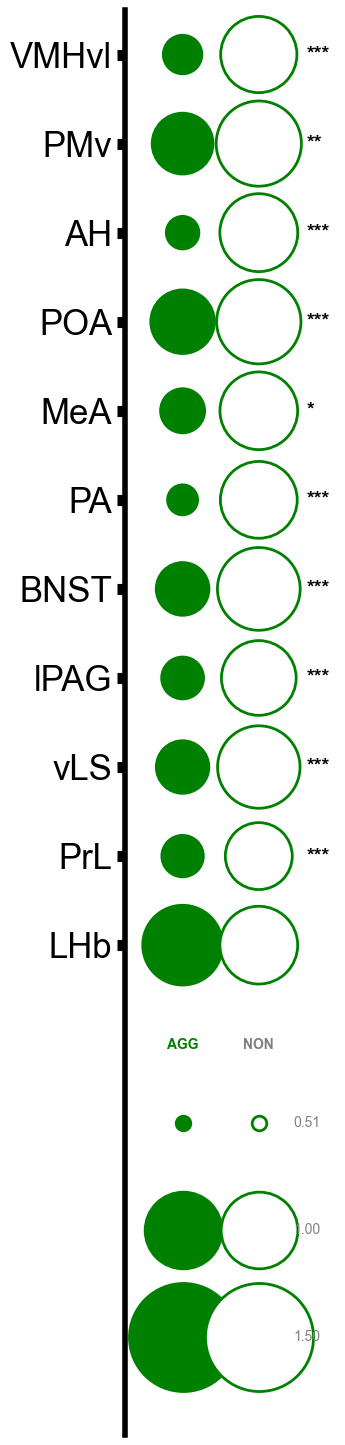

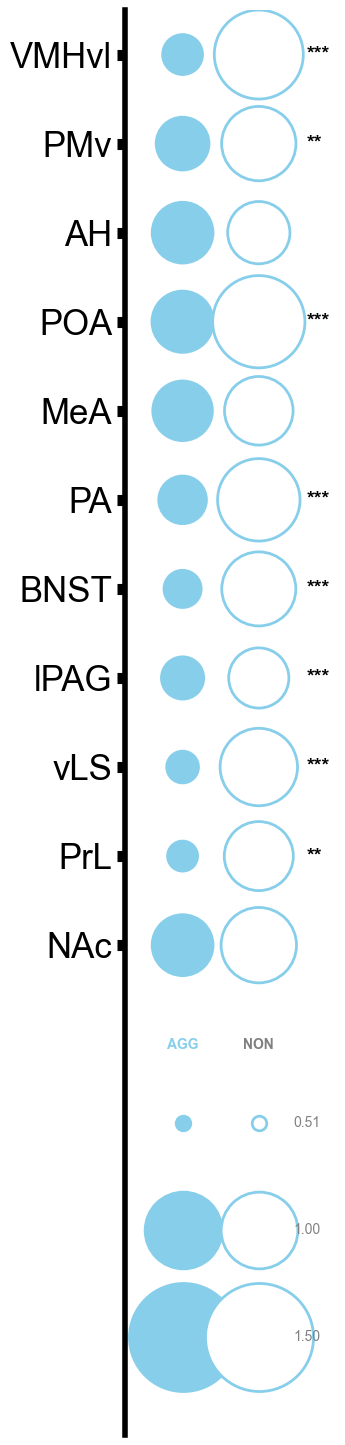

In [28]:
np.set_printoptions(precision=4, suppress=True)
region_ids = ['PrL (E)', 'PrL (I)', 'vLS (E)', 'vLS (I)', 'POA (E)', 'POA (I)',
	'BNST (E)', 'BNST (I)', 'AH (E)', 'AH (I)', 'MeA (E)', 'MeA (I)',
	'VMHvl (E)', 'VMHvl (I)', 'lPAG (E)', 'lPAG (I)', 'PMv (E)', 'PMv (I)', 'LHb (E)', 'LHb (I)', 
	'PA (E)', 'PA (I)', 'NAc (DA)']

mean_func = np.nanmedian

def compute_weights(arr):
    """
    Accepts either:
      3D (n_rois, n_obs, n_compare)         — already session-collapsed
      4D (n_sessions, n_rois, n_obs, n_compare) — full array
    Returns (weights_per_animal, weights_scalar) both shape (n_rois,)
    """
    arr = arr.copy()
    if arr.ndim == 4:
        # transpose to (n_rois, n_sessions, n_obs, n_compare)
        arr = np.transpose(arr, (1, 0, 2, 3))
        n_rois, n_sess, n_obs, n_compare = arr.shape
        arr = arr.reshape(n_rois, n_sess * n_obs, n_compare)
    elif arr.ndim == 3:
        # already (n_rois, n_obs, n_compare) — no reshape needed
        pass
    else:
        raise ValueError(f'Unexpected array ndim: {arr.ndim}')
    
    weights_per_animal = mean_func(arr, axis=-1)   # median over compare animals -> (n_rois, n_obs*n_sess)
    weights_scalar     = mean_func(weights_per_animal, axis=1)  # median over obs*sessions -> (n_rois,)
    return weights_per_animal, weights_scalar

weights2map_aggro, weights_aggro = compute_weights(obs_aggro)
weights2map_non,   weights_non   = compute_weights(obs_non)

vmin        = 0.5
vmax        = 1.5
size_factor = 6000
x_agg       = 0.8
x_non       = 1.2
x_sig       = 1.45

def get_sig_text(p_val):
    if p_val == 0:      return '****'
    elif p_val < 0.001: return '***'
    elif p_val < 0.01:  return '**'
    elif p_val < 0.05:  return '*'
    else:               return ''

def add_inline_legend(ax, color, vmin, vmax, size_factor,
                      x_aggro, x_non, y_start=-2.5):
    legend_vals  = [vmin + 0.01, (vmin + vmax) / 2, vmax]
    legend_sizes = (np.array(legend_vals) - vmin) / (vmax - vmin) * size_factor + 50
    y_leg        = y_start
    for val, sz in zip(legend_vals, legend_sizes):
        ax.scatter(x_aggro, y_leg, s=sz, facecolors=color,
                   edgecolors=color, linewidth=2, alpha=1.0, clip_on=False)
        ax.scatter(x_non,   y_leg, s=sz, facecolors='white',
                   edgecolors=color, linewidth=2, alpha=1.0, clip_on=False)
        ax.text(x_non + 0.18, y_leg, f'{val:.2f}',
                ha='left', va='center', fontsize=10, color='gray')
        y_leg -= 1.2
    ax.text(x_aggro, y_start + 0.8, 'AGG', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color=color)
    ax.text(x_non,   y_start + 0.8, 'NON', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='gray')

# ── Excitatory (no NAc DA) ───────────────────────────────────────────────────
new_idx_E       = np.array([12, 16, 8, 4, 10, 20, 6, 14, 2, 0, 18])[::-1]
weights_aggro_E = weights_aggro[new_idx_E]
weights_non_E   = weights_non[new_idx_E]
labels_E        = [x.replace(' (E)', '').replace(' (I)', '').replace(' (DA)', '')
                   for x in [region_ids[x] for x in new_idx_E]]
pvals_E         = p_adjusted[np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10])][::-1]

n_E   = len(new_idx_E)
y_pos = np.arange(n_E)

sizes_aggro_E = (np.clip(weights_aggro_E, vmin, vmax) - vmin) / (vmax - vmin) * size_factor + 50
sizes_non_E   = (np.clip(weights_non_E,   vmin, vmax) - vmin) / (vmax - vmin) * size_factor + 50

fig, ax = plt.subplots(figsize=(4, 15))
ax.scatter(np.ones(n_E) * x_agg, y_pos, s=sizes_aggro_E,
           facecolors='green', edgecolors='green', linewidth=2, alpha=1.0)
ax.scatter(np.ones(n_E) * x_non, y_pos, s=sizes_non_E,
           facecolors='white', edgecolors='green', linewidth=2, alpha=1.0)
for i, p_val in enumerate(pvals_E):
    sig = get_sig_text(p_val)
    if sig:
        ax.text(x_sig, y_pos[i], sig, ha='left', va='center',
                fontsize=14, fontweight='bold', color='black')
add_inline_legend(ax, 'green', vmin, vmax, size_factor,
                  x_aggro=x_agg, x_non=x_non, y_start=-2.0)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels_E, fontsize=25, fontfamily='Arial')
ax.set_xticks([])
ax.set_xlim(0.5, 1.6)
ax.set_ylim(-5.5, n_E - 0.5)
plt.tight_layout()
sns.despine(left=False, bottom=True)
plt.savefig('.\\figures\\fig4\\similarity_points_E_TP.svg', dpi=300)
plt.show()

# ── Inhibitory (with NAc DA appended) ────────────────────────────────────────
new_idx_I       = np.array([13, 17, 9, 5, 11, 21, 7, 15, 3, 1, 22])[::-1]
weights_aggro_I = weights_aggro[new_idx_I]
weights_non_I   = weights_non[new_idx_I]
labels_I        = [x.replace(' (E)', '').replace(' (I)', '').replace(' (DA)', '')
                   for x in [region_ids[x] for x in new_idx_I]]
pvals_I         = p_adjusted[np.array([11, 12, 13, 14, 15, 16, 17, 18, 19, 20, -1])][::-1]

n_I     = len(new_idx_I)
y_pos_I = np.arange(n_I)

sizes_aggro_I = (np.clip(weights_aggro_I, vmin, vmax) - vmin) / (vmax - vmin) * size_factor + 50
sizes_non_I   = (np.clip(weights_non_I,   vmin, vmax) - vmin) / (vmax - vmin) * size_factor + 50

fig, ax = plt.subplots(figsize=(4, 15))
ax.scatter(np.ones(n_I) * x_agg, y_pos_I, s=sizes_aggro_I,
           facecolors='skyblue', edgecolors='skyblue', linewidth=2, alpha=1.0)
ax.scatter(np.ones(n_I) * x_non, y_pos_I, s=sizes_non_I,
           facecolors='white', edgecolors='skyblue', linewidth=2, alpha=1.0)
for i, p_val in enumerate(pvals_I):
    sig = get_sig_text(p_val)
    if sig:
        ax.text(x_sig, y_pos_I[i], sig, ha='left', va='center',
                fontsize=14, fontweight='bold', color='black')
add_inline_legend(ax, 'skyblue', vmin, vmax, size_factor,
                  x_aggro=x_agg, x_non=x_non, y_start=-2.0)
ax.set_yticks(y_pos_I)
ax.set_yticklabels(labels_I, fontsize=25, fontfamily='Arial')
ax.set_xticks([])
ax.set_xlim(0.5, 1.6)
ax.set_ylim(-5.5, n_I - 0.5)
plt.tight_layout()
sns.despine(left=False, bottom=True)
plt.savefig('.\\figures\\fig4\\similarity_points_I_TP.svg', dpi=300)
plt.show()

OBS-AGG: E vs I                 U=4297241.000  p_raw=0.1476  p_fdr=0.1476
OBS-NON: E vs I                 U=2645593.000  p_raw=0.0711  p_fdr=0.0948
E: OBS-AGG vs NON               U=2328557.000  p_raw=0.0000  p_fdr=0.0000
I: OBS-AGG vs NON               U=2809520.000  p_raw=0.0000  p_fdr=0.0000


C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_18884\3327712491.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


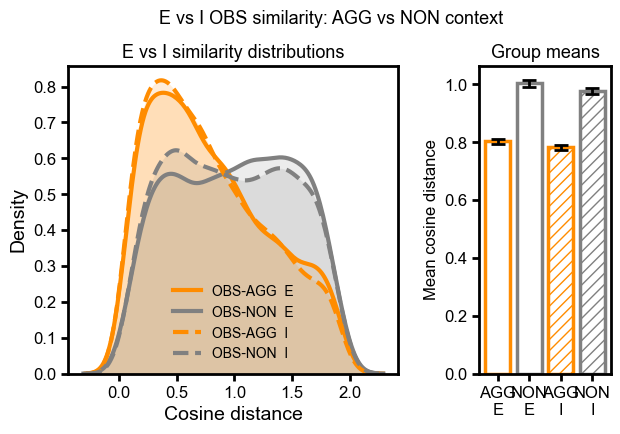

OBS-AGG: E vs I                 U=4297241.000  p_raw=0.1476  p_fdr=0.1476       n_a=  2781  n_b=  3024
OBS-NON: E vs I                 U=2645593.000  p_raw=0.0711  p_fdr=0.0948       n_a=  2160  n_b=  2376
E: OBS-AGG vs NON               U=2328557.000  p_raw=0.0000  p_fdr=0.0000 ***   n_a=  2781  n_b=  2160
I: OBS-AGG vs NON               U=2809520.000  p_raw=0.0000  p_fdr=0.0000 ***   n_a=  3024  n_b=  2376


In [30]:
from scipy.stats import ttest_ind, mannwhitneyu, shapiro
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.rcParams['font.family'] = 'Arial'

# --- Define idxs ---
I_idxs = np.array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19, 21])
E_idxs = np.array([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 20])

# --- Extract E vs I similarities ---
E_obs_aggro = obs_aggro[:, E_idxs]
E_obs_non   = obs_non[:, E_idxs]
I_obs_aggro = obs_aggro[:, I_idxs]
I_obs_non   = obs_non[:, I_idxs]

distb_EA = E_obs_aggro.flatten(); distb_EA = distb_EA[~np.isnan(distb_EA)]
distb_EN = E_obs_non.flatten();   distb_EN = distb_EN[~np.isnan(distb_EN)]
distb_IA = I_obs_aggro.flatten(); distb_IA = distb_IA[~np.isnan(distb_IA)]
distb_IN = I_obs_non.flatten();   distb_IN = distb_IN[~np.isnan(distb_IN)]

# --- Stats: 4 comparisons, FDR-BH corrected ---
def adaptive_test(a, b):
    """MWU if non-normal, t-test if both normal."""
    _, p1 = shapiro(a[:5000] if len(a) > 5000 else a)  # shapiro max N=5000
    _, p2 = shapiro(b[:5000] if len(b) > 5000 else b)
    if p1 > 0.05 and p2 > 0.05:
        stat, p = ttest_ind(a, b)
        return stat, p, 't'
    else:
        stat, p = mannwhitneyu(a, b, alternative='two-sided')
        return stat, p, 'U'

comparisons = {
    'OBS-AGG: E vs I':    (distb_EA, distb_IA),   # cross cell-type, aggro context
    'OBS-NON: E vs I':    (distb_EN, distb_IN),   # cross cell-type, non context
    'E: OBS-AGG vs NON':  (distb_EA, distb_EN),   # within E, group comparison
    'I: OBS-AGG vs NON':  (distb_IA, distb_IN),   # within I, group comparison
}

raw_p, stats_out = [], []
for label, (a, b) in comparisons.items():
    stat, p, test = adaptive_test(a, b)
    raw_p.append(p)
    stats_out.append({'label': label, 'stat': stat, 'p_raw': p, 'test': test})

_, p_corrected, _, _ = multipletests(raw_p, method='fdr_bh')
for i, d in enumerate(stats_out):
    d['p_fdr'] = p_corrected[i]
    print(f"{d['label']:30s}  {d['test']}={d['stat']:.3f}  p_raw={d['p_raw']:.4f}  p_fdr={d['p_fdr']:.4f}")

# --- Plot: single KDE panel + bar panel ---
fig = plt.figure(figsize=(7, 4))
gs  = fig.add_gridspec(1, 2, width_ratios=[2.5, 1], wspace=0.35)
ax_kde = fig.add_subplot(gs[0])
ax_bar = fig.add_subplot(gs[1])

# Color/style scheme: orange = OBS-AGG, gray = OBS-NON; solid = E, dashed = I
kde_specs = [
    (distb_EA, 'darkorange', '-',  'OBS-AGG  E'),
    (distb_EN, 'gray',       '-',  'OBS-NON  E'),
    (distb_IA, 'darkorange', '--', 'OBS-AGG  I'),
    (distb_IN, 'gray',       '--', 'OBS-NON  I'),
]
for dist, color, ls, label in kde_specs:
    sns.kdeplot(dist, ax=ax_kde, color=color, fill=True, alpha=0.15, lw=0)
    sns.kdeplot(dist, ax=ax_kde, color=color, lw=3, linestyle=ls, label=label)

ax_kde.set_xlabel('Cosine distance', fontsize=14)
ax_kde.set_ylabel('Density', fontsize=14)
ax_kde.legend(fontsize=10, frameon=False)
ax_kde.set_title('E vs I similarity distributions', fontsize=13)

# Bar plot: means ± SEM for the 4 vectors
means = [distb_EA.mean(), distb_EN.mean(), distb_IA.mean(), distb_IN.mean()]
sems  = [distb_EA.std()/np.sqrt(len(distb_EA)), distb_EN.std()/np.sqrt(len(distb_EN)),
         distb_IA.std()/np.sqrt(len(distb_IA)), distb_IN.std()/np.sqrt(len(distb_IN))]
colors    = ['darkorange', 'gray', 'darkorange', 'gray']
edgecolors= ['darkorange', 'gray', 'darkorange', 'gray']
hatches   = ['', '', '///', '///']   # hatching distinguishes I from E
xlabels   = ['AGG\nE', 'NON\nE', 'AGG\nI', 'NON\nI']

bars = ax_bar.bar(xlabels, means, yerr=sems, capsize=5,
                  color='white', edgecolor=edgecolors, linewidth=2.5,
                  error_kw=dict(lw=2, capthick=2))
for bar, hatch, ec in zip(bars, hatches, edgecolors):
    bar.set_hatch(hatch)
    bar.set_edgecolor(ec)

# Annotate significant comparisons with brackets
def draw_bracket(ax, x1, x2, y, p, h=0.005):
    """Draw a significance bracket between bar positions x1 and x2."""
    if p < 0.001:   sig = '***'
    elif p < 0.01:  sig = '**'
    elif p < 0.05:  sig = '*'
    else:           sig = 'ns'
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, color='black')
    ax.text((x1+x2)/2, y+h, sig, ha='center', va='bottom', fontsize=11)

ymax = max(m+s for m, s in zip(means, sems))
step = 0.015
# Within-group cross cell-type (E vs I): AGG_E(0) vs AGG_I(2), NON_E(1) vs NON_I(3)
# draw_bracket(ax_bar, 0, 2, ymax + step,   stats_out[0]['p_fdr'])   # OBS-AGG: E vs I
# draw_bracket(ax_bar, 1, 3, ymax + step*3, stats_out[1]['p_fdr'])   # OBS-NON: E vs I
# Within cell-type group comparisons: E_AGG(0) vs E_NON(1), I_AGG(2) vs I_NON(3)
# draw_bracket(ax_bar, 0, 1, ymax + step*5, stats_out[2]['p_fdr'])   # E: AGG vs NON
# draw_bracket(ax_bar, 2, 3, ymax + step*7, stats_out[3]['p_fdr'])   # I: AGG vs NON

ax_bar.set_ylabel('Mean cosine distance', fontsize=12)
ax_bar.set_title('Group means', fontsize=13)
ax.set_ylim(top = 1.1)

for ax in [ax_kde, ax_bar]:
    ax.tick_params(axis='both', labelsize=12, width=2, length=5)
    for spine in ax.spines.values():
        spine.set_linewidth(2)

plt.suptitle('E vs I OBS similarity: AGG vs NON context', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('.\\figures\\fig4\\similarity_E_vs_I_kde_bar_TP.svg', dpi=300)
plt.show()

for i, d in enumerate(stats_out):
    label = d['label']
    a, b  = list(comparisons.values())[i]
    sig   = get_sig(d['p_fdr'])
    print(f"{label:<30}  {d['test']}={d['stat']:>10.3f}  "
          f"p_raw={d['p_raw']:.4f}  p_fdr={d['p_fdr']:.4f} {sig:<4}  "
          f"n_a={len(a):>6}  n_b={len(b):>6}")